<a href="https://colab.research.google.com/github/ZarinRitu32/Myopia_ML/blob/main/SoftCom_05_Figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SoftCom myopia-risk benchmark - Section 5 - Paper-style visualisations

Reproduction and extension of Mu et al. 2024 (Front. Med. 11:1482788) on the provided **hybrid cohort (N=1500)**. Pipeline validation only - no clinical claims.

**Pipeline:** SoftCom_01_Data_Validation -> SoftCom_02_Preprocessing -> SoftCom_03_Benchmarking -> SoftCom_04_Explainable_AI -> **SoftCom_05_Figures** -> SoftCom_06_Export

All inputs and outputs live in Google Drive at `MyDrive/SoftCom_Myopia/`. Each notebook checks `artifacts/manifest.json` and stops if an upstream step has not run or its files have changed.

| | |
|---|---|
| **Reads** | outputs of 02 and 03 |
| **Writes** | `figures/fig2_prevalence`, `fig4_distributions`, `fig5_roc_train_test`, `fig8_heatmap`, `tables/table7-8` |
| **Next** | `SoftCom_06_Export.ipynb` |

Runtime: Colab CPU is enough. Use *Runtime -> Run all*; accept the Drive prompt in the setup cell. For a quick trial run, set `"FAST_MODE": True` in the CONFIG cell of **every** notebook (fewer CV repeats/bootstraps); set it back to `False` for the reported results.

## 0. Install dependencies and set up Google Drive

In [ ]:
%pip install -q "shap>=0.47" xgboost lightgbm statsmodels imbalanced-learn

In [ ]:
"""Shared setup (identical in every SoftCom notebook).

Mounts Google Drive, defines CONFIG, the Drive folder layout, the run manifest
that links the six notebooks together, seeding, logging and figure helpers.
"""
from __future__ import annotations

import hashlib
import json
import os
import random
import shutil
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Callable, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# ----------------------------------------------------------------------------- CONFIG
CONFIG: Dict[str, Any] = {
    "SEED": 42,
    "TEST_SIZE": 0.3,
    "N_SPLITS": 5,
    "N_REPEATS": 10,
    "N_BOOTSTRAP": 2000,
    "EXPECTED_N_ROWS": 1500,
    "DATA_FILENAME": "full_myopia_hybrid_dataset_N1500.csv",
    "PILOT_FILENAME": "pilot_real.csv",          # optional 73-row pilot; never merged
    "TARGET": "is_myopic",
    "SOURCE_LABEL": "hybrid",
    "COHORT_LABEL": "Hybrid cohort (N=1500) - pipeline validation only, not clinical evidence",
    "DRIVE_PROJECT_DIR": "SoftCom_Myopia",       # folder inside MyDrive holding everything
    "USE_SMOTE": False,                          # SMOTE inside pipeline only (imblearn)
    "USE_LASSO_SELECTION": True,                 # L1-logistic SelectFromModel inside pipeline
    "ABLATION": True,                            # also run FT-Transformer without attention
    "DEEP_MAX_EPOCHS": 200,
    "DEEP_PATIENCE": 20,
    "DEEP_BATCH_SIZE": 64,
    "PERM_N_REPEATS": 20,
    "SHAP_BACKGROUND": 100,
    "SHAP_N_EXPLAIN": 150,
    "SHAP_KERNEL_NSAMPLES": 200,
    "FAST_MODE": False,                          # True = quick trial run (same value in all notebooks)
}
CONFIG["FAST_MODE"] |= os.environ.get("SOFTCOM_FAST", "0") == "1"  # local smoke tests
if CONFIG["FAST_MODE"]:
    CONFIG.update(N_REPEATS=2, N_BOOTSTRAP=200, DEEP_MAX_EPOCHS=25, DEEP_PATIENCE=5,
                  PERM_N_REPEATS=3, SHAP_BACKGROUND=20, SHAP_N_EXPLAIN=20,
                  SHAP_KERNEL_NSAMPLES=60)
SEED: int = CONFIG["SEED"]

NOTEBOOKS: Dict[str, str] = {
    "01_data": "SoftCom_01_Data_Validation.ipynb",
    "02_preprocessing": "SoftCom_02_Preprocessing.ipynb",
    "03_benchmark": "SoftCom_03_Benchmarking.ipynb",
    "04_xai": "SoftCom_04_Explainable_AI.ipynb",
    "05_figures": "SoftCom_05_Figures.ipynb",
    "06_export": "SoftCom_06_Export.ipynb",
}

# ----------------------------------------------------------------------------- Drive
LAUNCH_DIR: Path = Path.cwd()
try:
    from google.colab import drive  # type: ignore

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not Path("/content/drive/MyDrive").is_dir():
        try:
            drive.mount("/content/drive")
        except Exception as exc:  # pragma: no cover - interactive auth
            raise RuntimeError(
                "Google Drive mount failed. Re-run this cell and accept the Drive "
                f"authorisation prompt. Original error: {exc}"
            ) from exc
    PROJECT_ROOT = Path("/content/drive/MyDrive") / CONFIG["DRIVE_PROJECT_DIR"]
else:
    PROJECT_ROOT = Path(os.environ.get("SOFTCOM_ROOT", LAUNCH_DIR / CONFIG["DRIVE_PROJECT_DIR"])).resolve()

DIRS: Dict[str, Path] = {
    name: PROJECT_ROOT / sub
    for name, sub in {
        "raw": "data/raw",
        "processed": "data/processed",
        "models": "models",
        "predictions": "predictions",
        "tables": "tables",
        "figures": "figures",
        "artifacts": "artifacts",
        "logs": "logs",
    }.items()
}
for _d in DIRS.values():
    _d.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_ROOT)  # so ./figures/ and ./tables/ resolve inside Google Drive
MANIFEST_PATH: Path = DIRS["artifacts"] / "manifest.json"


# ----------------------------------------------------------------------------- helpers
def set_global_seed(seed: int = SEED) -> None:
    """Seed python, numpy and (if installed) torch for reproducible runs."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch  # type: ignore

        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True, warn_only=True)
    except ImportError:
        pass


def log(step: str, message: str) -> None:
    """Print a message and append it to logs/<step>.log on Drive."""
    stamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S")
    print(message)
    with open(DIRS["logs"] / f"{step}.log", "a", encoding="utf-8") as fh:
        fh.write(f"[{stamp}] {message}\n")


def sha256_file(path: Path) -> str:
    """Return the SHA-256 hex digest of a file."""
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def rel(path: Path) -> str:
    """Path relative to the project root (as stored in the manifest)."""
    return str(Path(path).resolve().relative_to(PROJECT_ROOT))


def _atomic_write_json(obj: Any, path: Path) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w", encoding="utf-8") as fh:
        json.dump(obj, fh, indent=2, default=str)
    os.replace(tmp, path)


def save_json(obj: Any, path: Path) -> Path:
    """Write JSON atomically (numpy/pandas values are stringified if needed)."""
    _atomic_write_json(obj, path)
    return path


def load_manifest() -> Dict[str, Any]:
    """Load the cross-notebook run manifest (empty skeleton if absent)."""
    if MANIFEST_PATH.exists():
        with open(MANIFEST_PATH, encoding="utf-8") as fh:
            return json.load(fh)
    return {"project": "SoftCom myopia benchmark", "steps": {}}


def register_outputs(step: str, paths: Iterable[Path], extra: Optional[Dict[str, Any]] = None) -> None:
    """Record a finished notebook step and the SHA-256 of every file it wrote."""
    manifest = load_manifest()
    files = {}
    for p in paths:
        p = Path(p)
        if not p.exists():
            raise FileNotFoundError(f"[{step}] expected output was not written: {p}")
        files[rel(p)] = sha256_file(p)
    manifest["steps"][step] = {
        "notebook": NOTEBOOKS[step],
        "status": "ok",
        "finished_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "fast_mode": CONFIG["FAST_MODE"],
        "outputs": files,
        "extra": extra or {},
    }
    _atomic_write_json(manifest, MANIFEST_PATH)
    print(f"Manifest updated: step '{step}' -> {len(files)} files registered.")


def require_upstream(step: str, needed: Sequence[str]) -> None:
    """Fail loudly unless `step` ran successfully and its files are unchanged.

    `needed` are project-relative paths that this notebook will read.
    """
    manifest = load_manifest()
    info = manifest["steps"].get(step)
    if info is None or info.get("status") != "ok":
        raise RuntimeError(
            f"Upstream step '{step}' has not completed. Open and 'Run all' "
            f"{NOTEBOOKS[step]} first (results folder: {PROJECT_ROOT})."
        )
    for r in needed:
        p = PROJECT_ROOT / r
        if not p.exists():
            raise FileNotFoundError(f"Missing upstream file {r}; re-run {NOTEBOOKS[step]}.")
        expected = info["outputs"].get(r)
        if expected is None:
            raise RuntimeError(f"{r} is not registered by {NOTEBOOKS[step]}; re-run it.")
        if sha256_file(p) != expected:
            raise RuntimeError(
                f"{r} changed after {NOTEBOOKS[step]} finished (hash drift). "
                f"Re-run {NOTEBOOKS[step]} and the notebooks after it."
            )
    if info.get("fast_mode") != CONFIG["FAST_MODE"]:
        print(f"WARNING: {step} ran with FAST_MODE={info.get('fast_mode')}, this notebook uses "
              f"FAST_MODE={CONFIG['FAST_MODE']}.")
    print(f"Upstream OK: {step} ({info['finished_at']}), {len(needed)} files verified.")


sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                     "legend.fontsize": 10, "savefig.bbox": "tight"})


def save_figure(fig: plt.Figure, name: str, footnote: bool = True) -> List[Path]:
    """Save `fig` as 300-DPI PNG and SVG in ./figures/ (on Drive) and close it."""
    if footnote:  # place below everything already drawn (rotated tick labels included)
        bottom = fig.get_tightbbox(fig.canvas.get_renderer()).y0 / fig.get_figheight()
        fig.text(0.995, min(bottom, 0.0) - 0.01, CONFIG["COHORT_LABEL"], ha="right", va="top", fontsize=8, color="0.45")
    out = []
    try:
        for ext in ("png", "svg"):
            p = DIRS["figures"] / f"{name}.{ext}"
            fig.savefig(p, dpi=300, bbox_inches="tight")
            out.append(p)
    except OSError as exc:
        raise RuntimeError(f"Could not write figure {name} to {DIRS['figures']}: {exc}") from exc
    finally:
        plt.close(fig)
    print(f"Saved figure: figures/{name}.png + .svg")
    return out


def show_saved(name: str) -> None:
    """Display a saved PNG inline (Colab/Jupyter only)."""
    try:
        from IPython.display import Image, display  # type: ignore

        if "ipykernel" in sys.modules:
            display(Image(filename=str(DIRS["figures"] / f"{name}.png"), width=720))
    except ImportError:
        pass


set_global_seed(SEED)
print(f"Colab: {IN_COLAB} | results folder: {PROJECT_ROOT} | FAST_MODE={CONFIG['FAST_MODE']}")

Mounted at /content/drive
Colab: True | results folder: /content/drive/MyDrive/SoftCom_Myopia | FAST_MODE=False


## 5.1 Load cohort, predictions and performance tables

In [ ]:
from scipy.stats import chi2_contingency, mannwhitneyu, norm
from sklearn.metrics import roc_curve

STEP = "05_figures"
require_upstream("02_preprocessing", ["data/processed/cohort_features.csv", "artifacts/feature_spec.json"])
require_upstream("03_benchmark", ["predictions/holdout_test_predictions.csv", "predictions/holdout_train_predictions.csv",
                                  "tables/table2c_holdout_detail.csv"])
with open(DIRS["artifacts"] / "feature_spec.json", encoding="utf-8") as fh:
    FSPEC = json.load(fh) # Corrected json.json_load to json.load
TARGET = FSPEC["target"]
df = pd.read_csv(DIRS["processed"] / "cohort_features.csv")
pred_te = pd.read_csv(DIRS["predictions"] / "holdout_test_predictions.csv")
pred_tr = pd.read_csv(DIRS["predictions"] / "holdout_train_predictions.csv")
holdout = pd.read_csv(DIRS["tables"] / "table2c_holdout_detail.csv", index_col="Model")
MODELS = list(holdout.index)
LABELS = {0: "No myopia", 1: "Myopia"}
fig_paths: List[Path] = []
print(f"{len(df)} rows | models: {MODELS}")

Upstream OK: 02_preprocessing (2026-09-24T16:50:58+00:00), 2 files verified.
Upstream OK: 03_benchmark (2026-09-24T17:19:57+00:00), 3 files verified.
1500 rows | models: ['LR', 'DT', 'RF', 'XGBoost', 'SVM', 'LightGBM', 'Stacking', 'MLP', 'FT-Transformer', 'FT-Transformer-noAttn']


## 5.2 Figure 2 - prevalence by age group with Wilson 95% CI and chi-square test

Saved figure: figures/fig2_prevalence.png + .svg


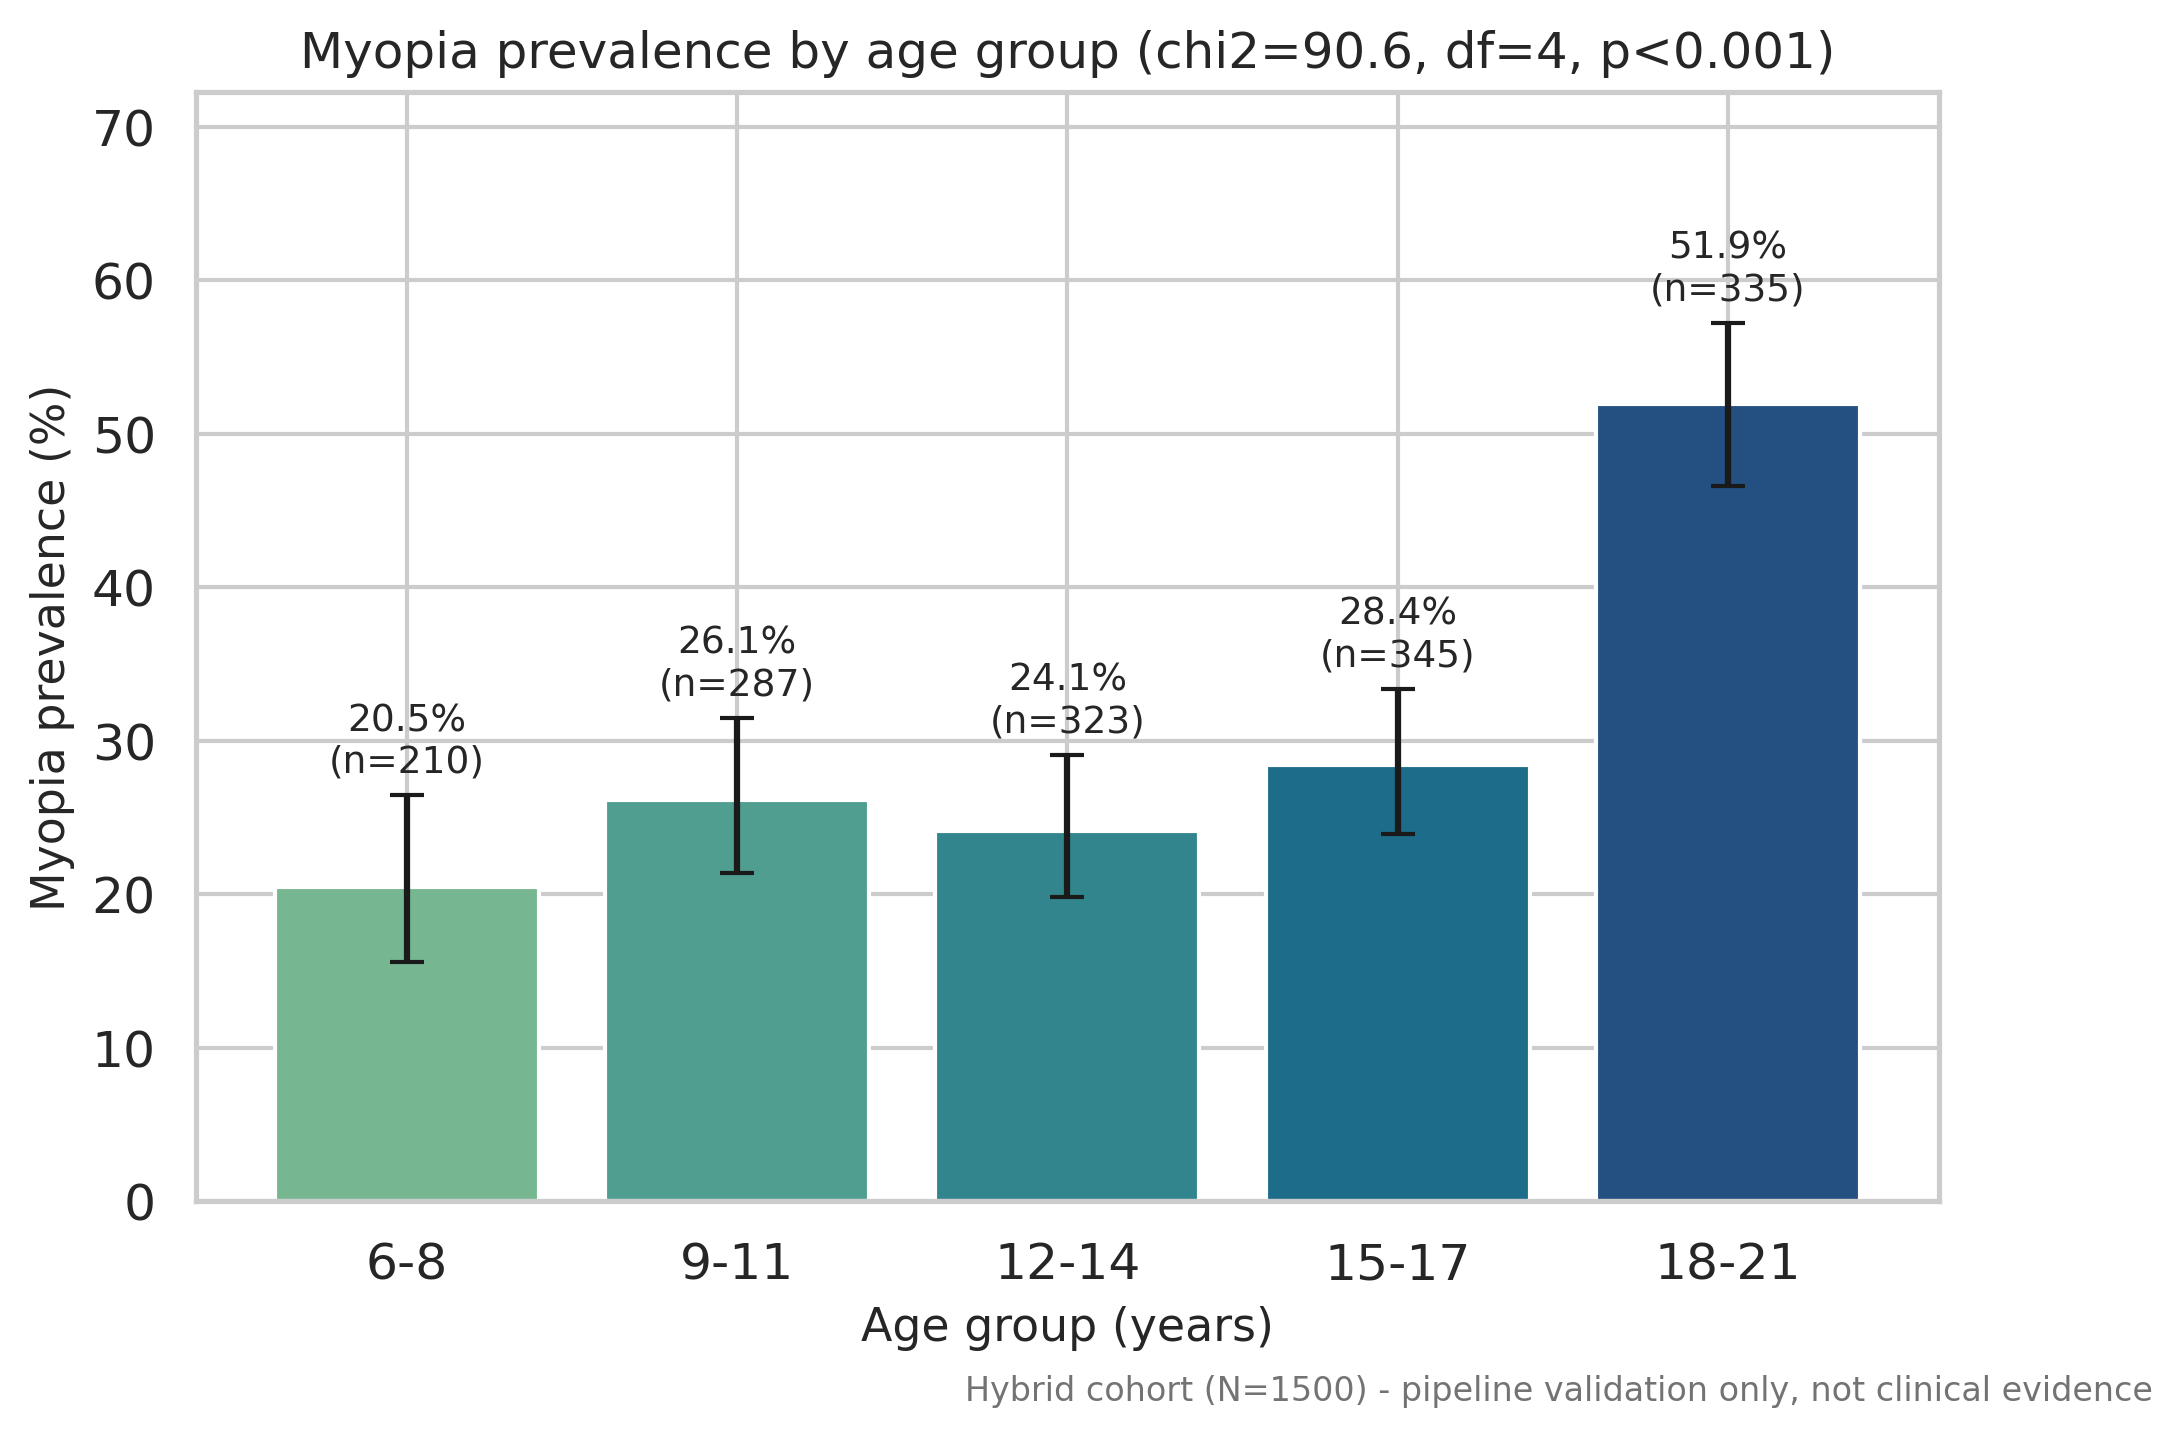

age_group   n  myopic  prevalence  ci_low  ci_high
      6-8 210      43       0.205   0.156    0.264
     9-11 287      75       0.261   0.214    0.315
    12-14 323      78       0.241   0.198    0.291
    15-17 345      98       0.284   0.239    0.334
    18-21 335     174       0.519   0.466    0.572


In [ ]:
def wilson_ci(k: int, n: int, alpha: float = 0.05) -> Tuple[float, float]:
    """Wilson score interval for a binomial proportion."""
    if n == 0:
        return (np.nan, np.nan)
    z = norm.ppf(1 - alpha / 2)
    p = k / n
    centre = (p + z * z / (2 * n)) / (1 + z * z / n)
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return centre - half, centre + half


bins = [5, 8, 11, 14, 17, 25]
labels = ["6-8", "9-11", "12-14", "15-17", "18-21"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)
prev_rows = []
for g, sub in df.groupby("age_group", observed=True):
    k, n = int(sub[TARGET].sum()), len(sub)
    lo, hi = wilson_ci(k, n)
    prev_rows.append({"age_group": g, "n": n, "myopic": k, "prevalence": k / n, "ci_low": lo, "ci_high": hi})
prev_df = pd.DataFrame(prev_rows)
chi2, p_chi, dof, _ = chi2_contingency(pd.crosstab(df["age_group"], df[TARGET]))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.bar(prev_df.age_group.astype(str), prev_df.prevalence * 100, color=sns.color_palette("crest", len(prev_df)),
       yerr=[(prev_df.prevalence - prev_df.ci_low) * 100, (prev_df.ci_high - prev_df.prevalence) * 100], capsize=4)
for i, r in prev_df.iterrows():
    ax.text(i, r.ci_high * 100 + 1.5, f"{r.prevalence * 100:.1f}%\n(n={r.n})", ha="center", fontsize=9)
ptxt = "p<0.001" if p_chi < 0.001 else f"p={p_chi:.3f}"
ax.set(xlabel="Age group (years)", ylabel="Myopia prevalence (%)", ylim=(0, min(100, prev_df.ci_high.max() * 100 + 15)),
       title=f"Myopia prevalence by age group (chi2={chi2:.1f}, df={dof}, {ptxt})")
fig_paths += save_figure(fig, "fig2_prevalence")
show_saved("fig2_prevalence")
print(prev_df.round(3).to_string(index=False))

## 5.3 Figure 4 - distributions of AL, SE, AL/CR and age by myopia status

Saved figure: figures/fig4_distributions.png + .svg


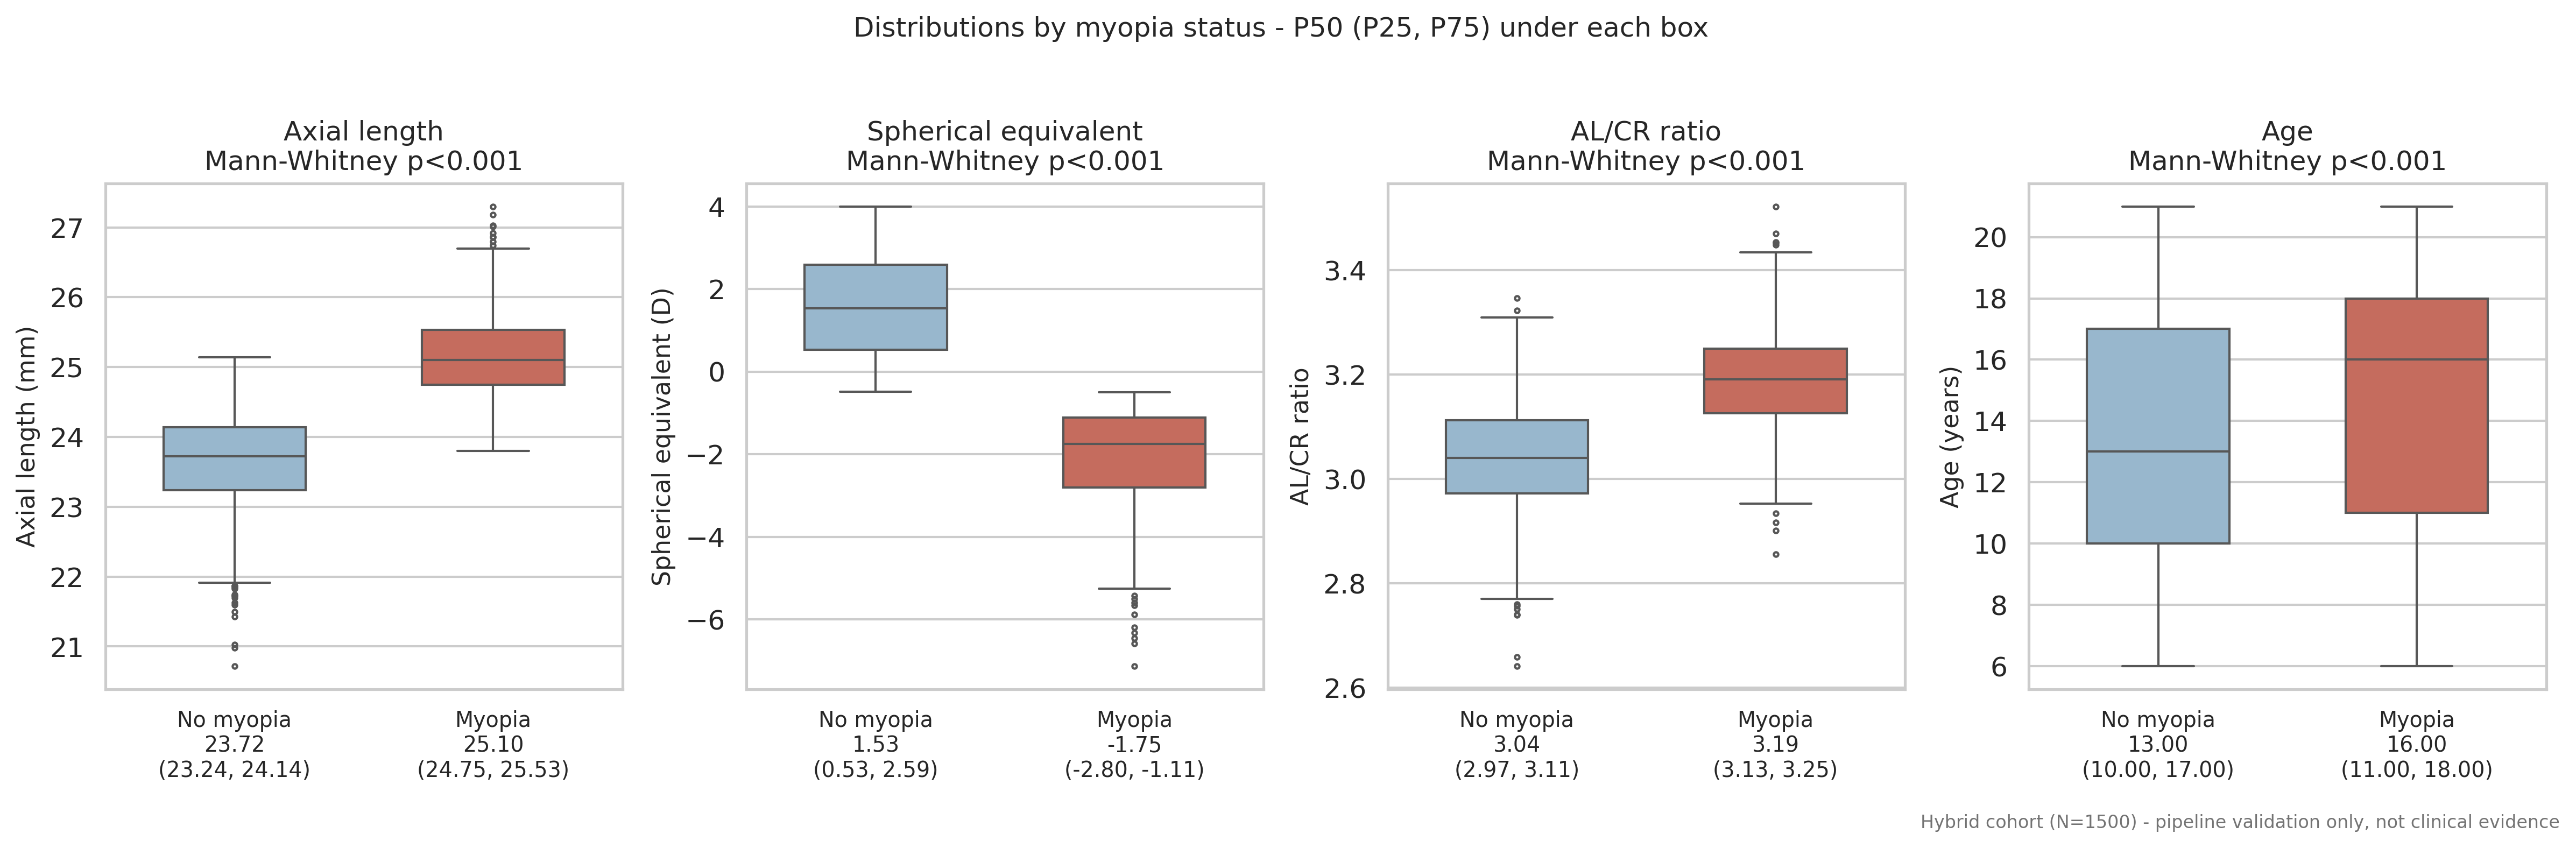

In [ ]:
panels = [("axial_length_mm", "Axial length (mm)"), ("spherical_equivalent_d", "Spherical equivalent (D)"),
          ("al_cr_ratio", "AL/CR ratio"), ("age", "Age (years)")]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.8))
plot_df = df.assign(group=df[TARGET].map(LABELS))
for ax, (col, lab) in zip(axes, panels):
    sns.boxplot(data=plot_df, x="group", y=col, hue="group", order=list(LABELS.values()), palette=["#8fb9d6", "#d6604d"],
                width=0.55, fliersize=2, legend=False, ax=ax)
    ticks = []
    for g in LABELS.values():
        s = plot_df.loc[plot_df.group == g, col]
        ticks.append(f"{g}\n{s.median():.2f}\n({s.quantile(.25):.2f}, {s.quantile(.75):.2f})")
    ax.set_xticks([0, 1], ticks, fontsize=9.5)
    p = mannwhitneyu(plot_df.loc[plot_df[TARGET] == 0, col], plot_df.loc[plot_df[TARGET] == 1, col]).pvalue
    ax.set(xlabel="", ylabel=lab, title=f"{lab.split(' (')[0]}\nMann-Whitney {'p<0.001' if p < 0.001 else f'p={p:.3f}'}")
fig.suptitle("Distributions by myopia status - P50 (P25, P75) under each box", y=1.02, fontsize=12)
fig.tight_layout()
fig_paths += save_figure(fig, "fig4_distributions")
show_saved("fig4_distributions")

## 5.4 Figure 5 - ROC curves: (A) training split, (B) holdout test split

Saved figure: figures/fig5_roc_train_test.png + .svg


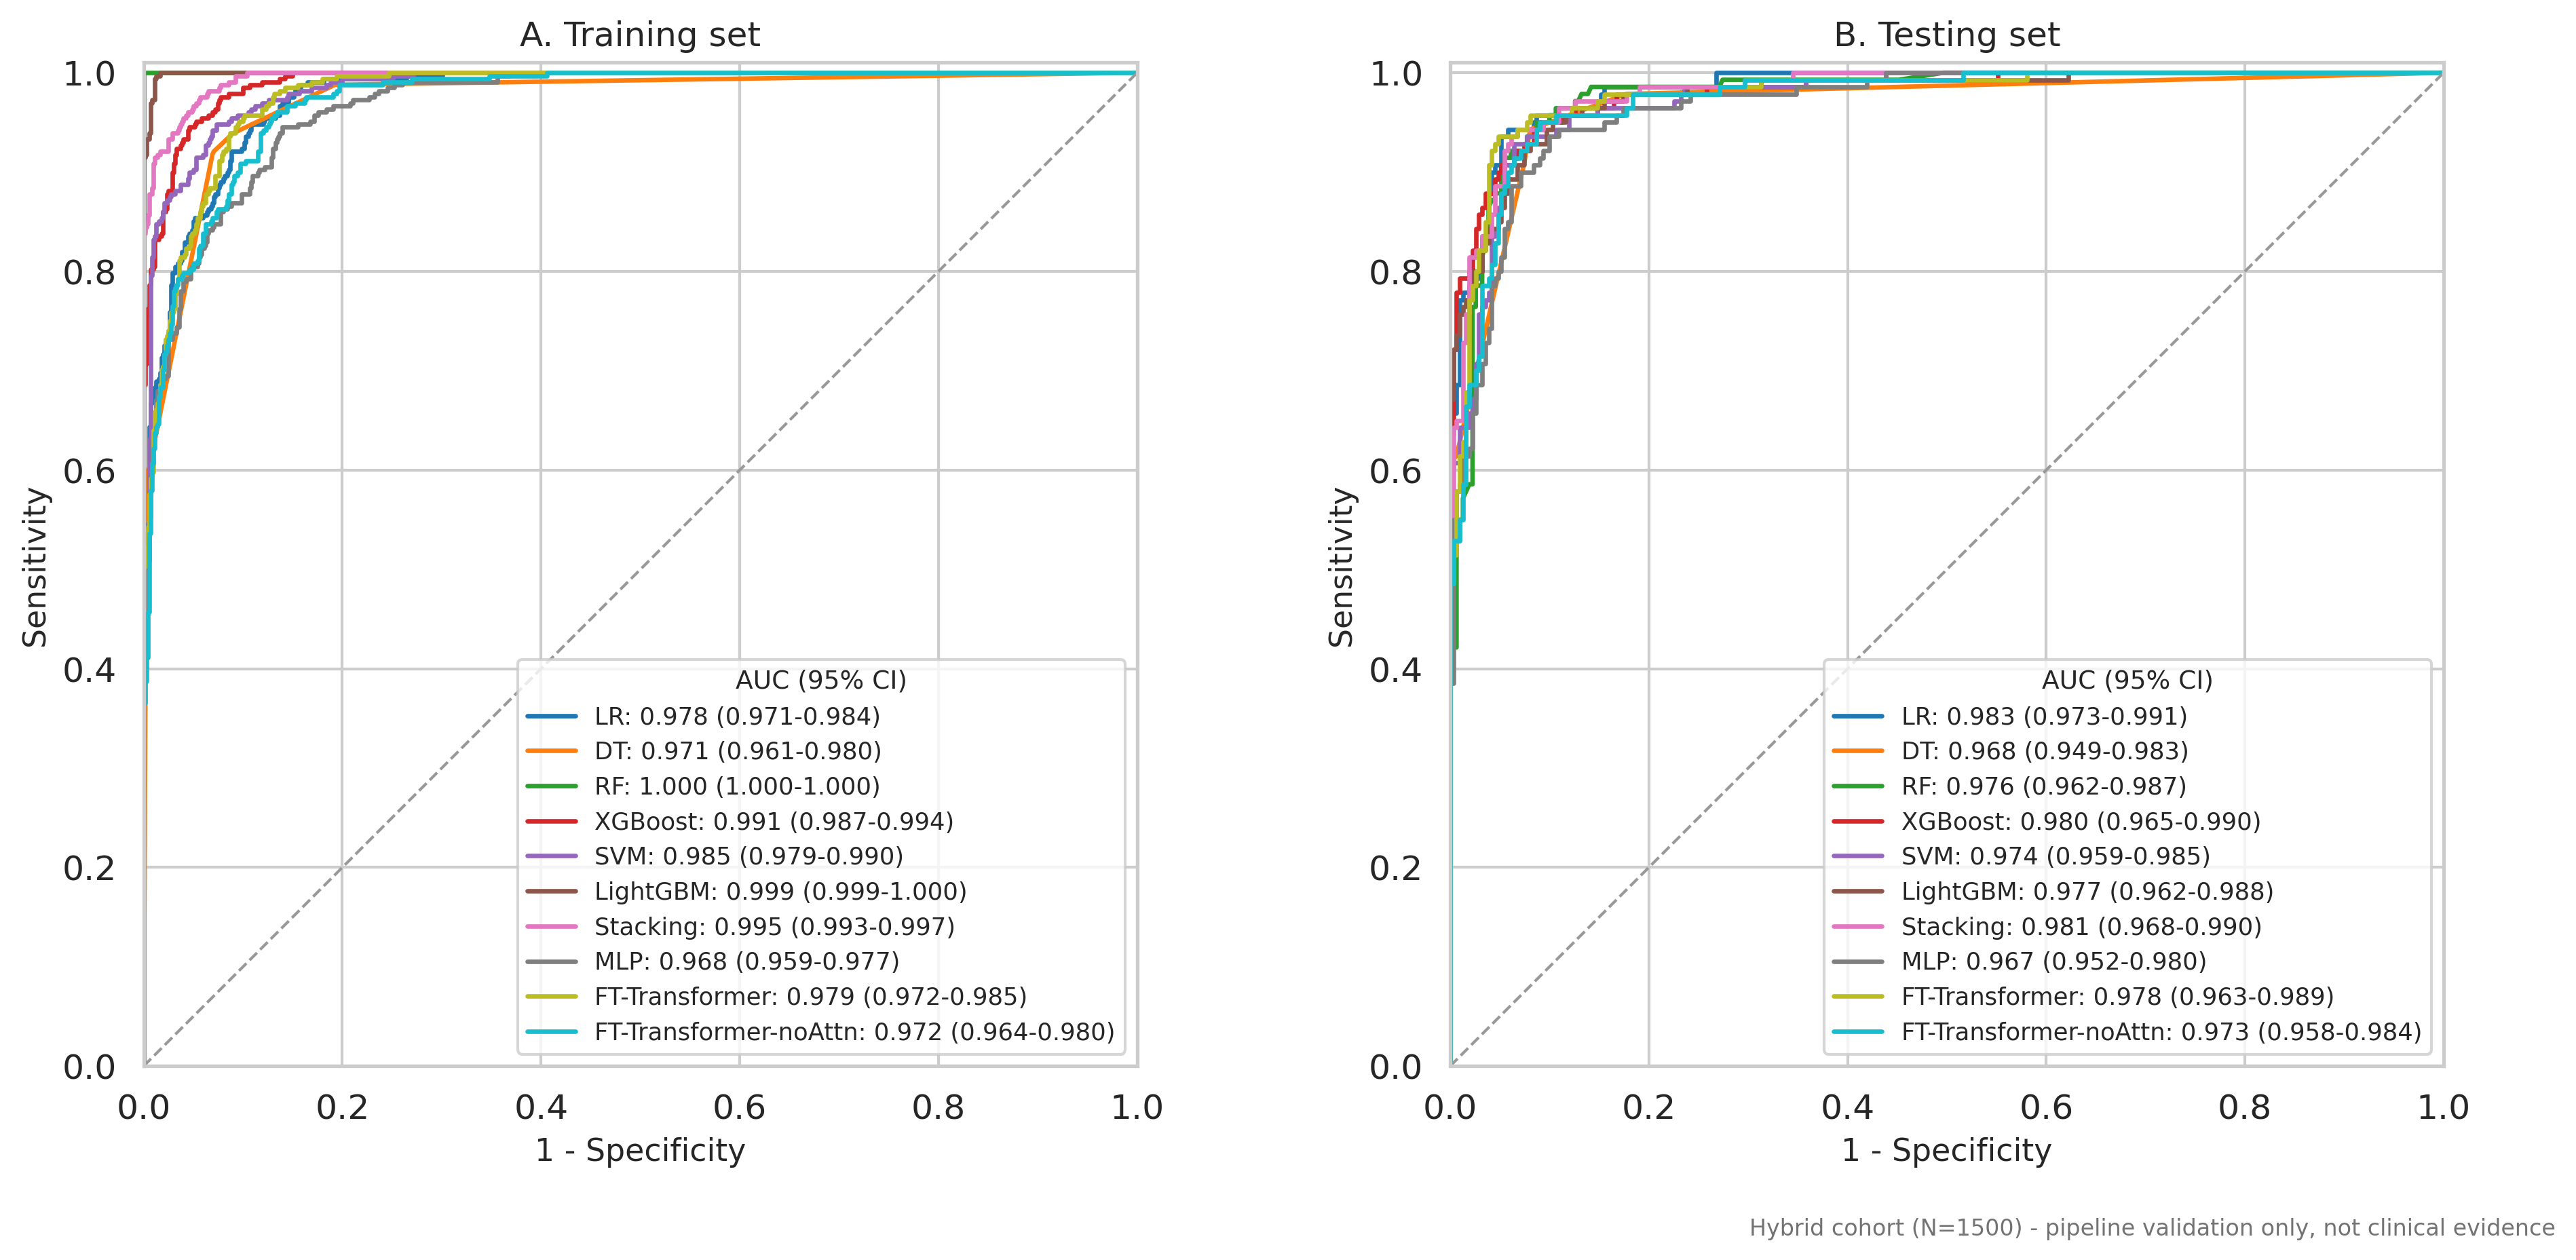

In [ ]:
MODELS = pred_te.columns[2:].tolist() # Re-deriving MODELS to ensure it contains string model names
palette = dict(zip(MODELS, sns.color_palette("tab10", len(MODELS))))
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, preds, tag, prefix in [(axes[0], pred_tr, "A. Training set", "train_"), (axes[1], pred_te, "B. Testing set", "")]:
    for m in MODELS:
        fpr, tpr, _ = roc_curve(preds["y"], preds[m])
        auc_ = holdout.loc[m, f"{prefix}auc" if prefix else "roc_auc"]
        lo, hi = holdout.loc[m, f"{prefix}auc_ci_low"], holdout.loc[m, f"{prefix}auc_ci_high"]
        ax.plot(fpr, tpr, lw=1.6, color=palette[m], label=f"{m}: {auc_:.3f} ({lo:.3f}-{hi:.3f})")
    ax.plot([0, 1], [0, 1], ls="--", color="0.6", lw=1)
    ax.set(xlim=(0, 1), ylim=(0, 1.01), xlabel="1 - Specificity", ylabel="Sensitivity", title=tag, aspect="equal")
    ax.legend(title="AUC (95% CI)", loc="lower right", fontsize=8.5, title_fontsize=9)
fig.tight_layout()
fig_paths += save_figure(fig, "fig5_roc_train_test")
show_saved("fig5_roc_train_test")

## 5.5 Figure 8 - Spearman correlation heatmap (all features, SE and outcome)

Saved figure: figures/fig8_heatmap.png + .svg


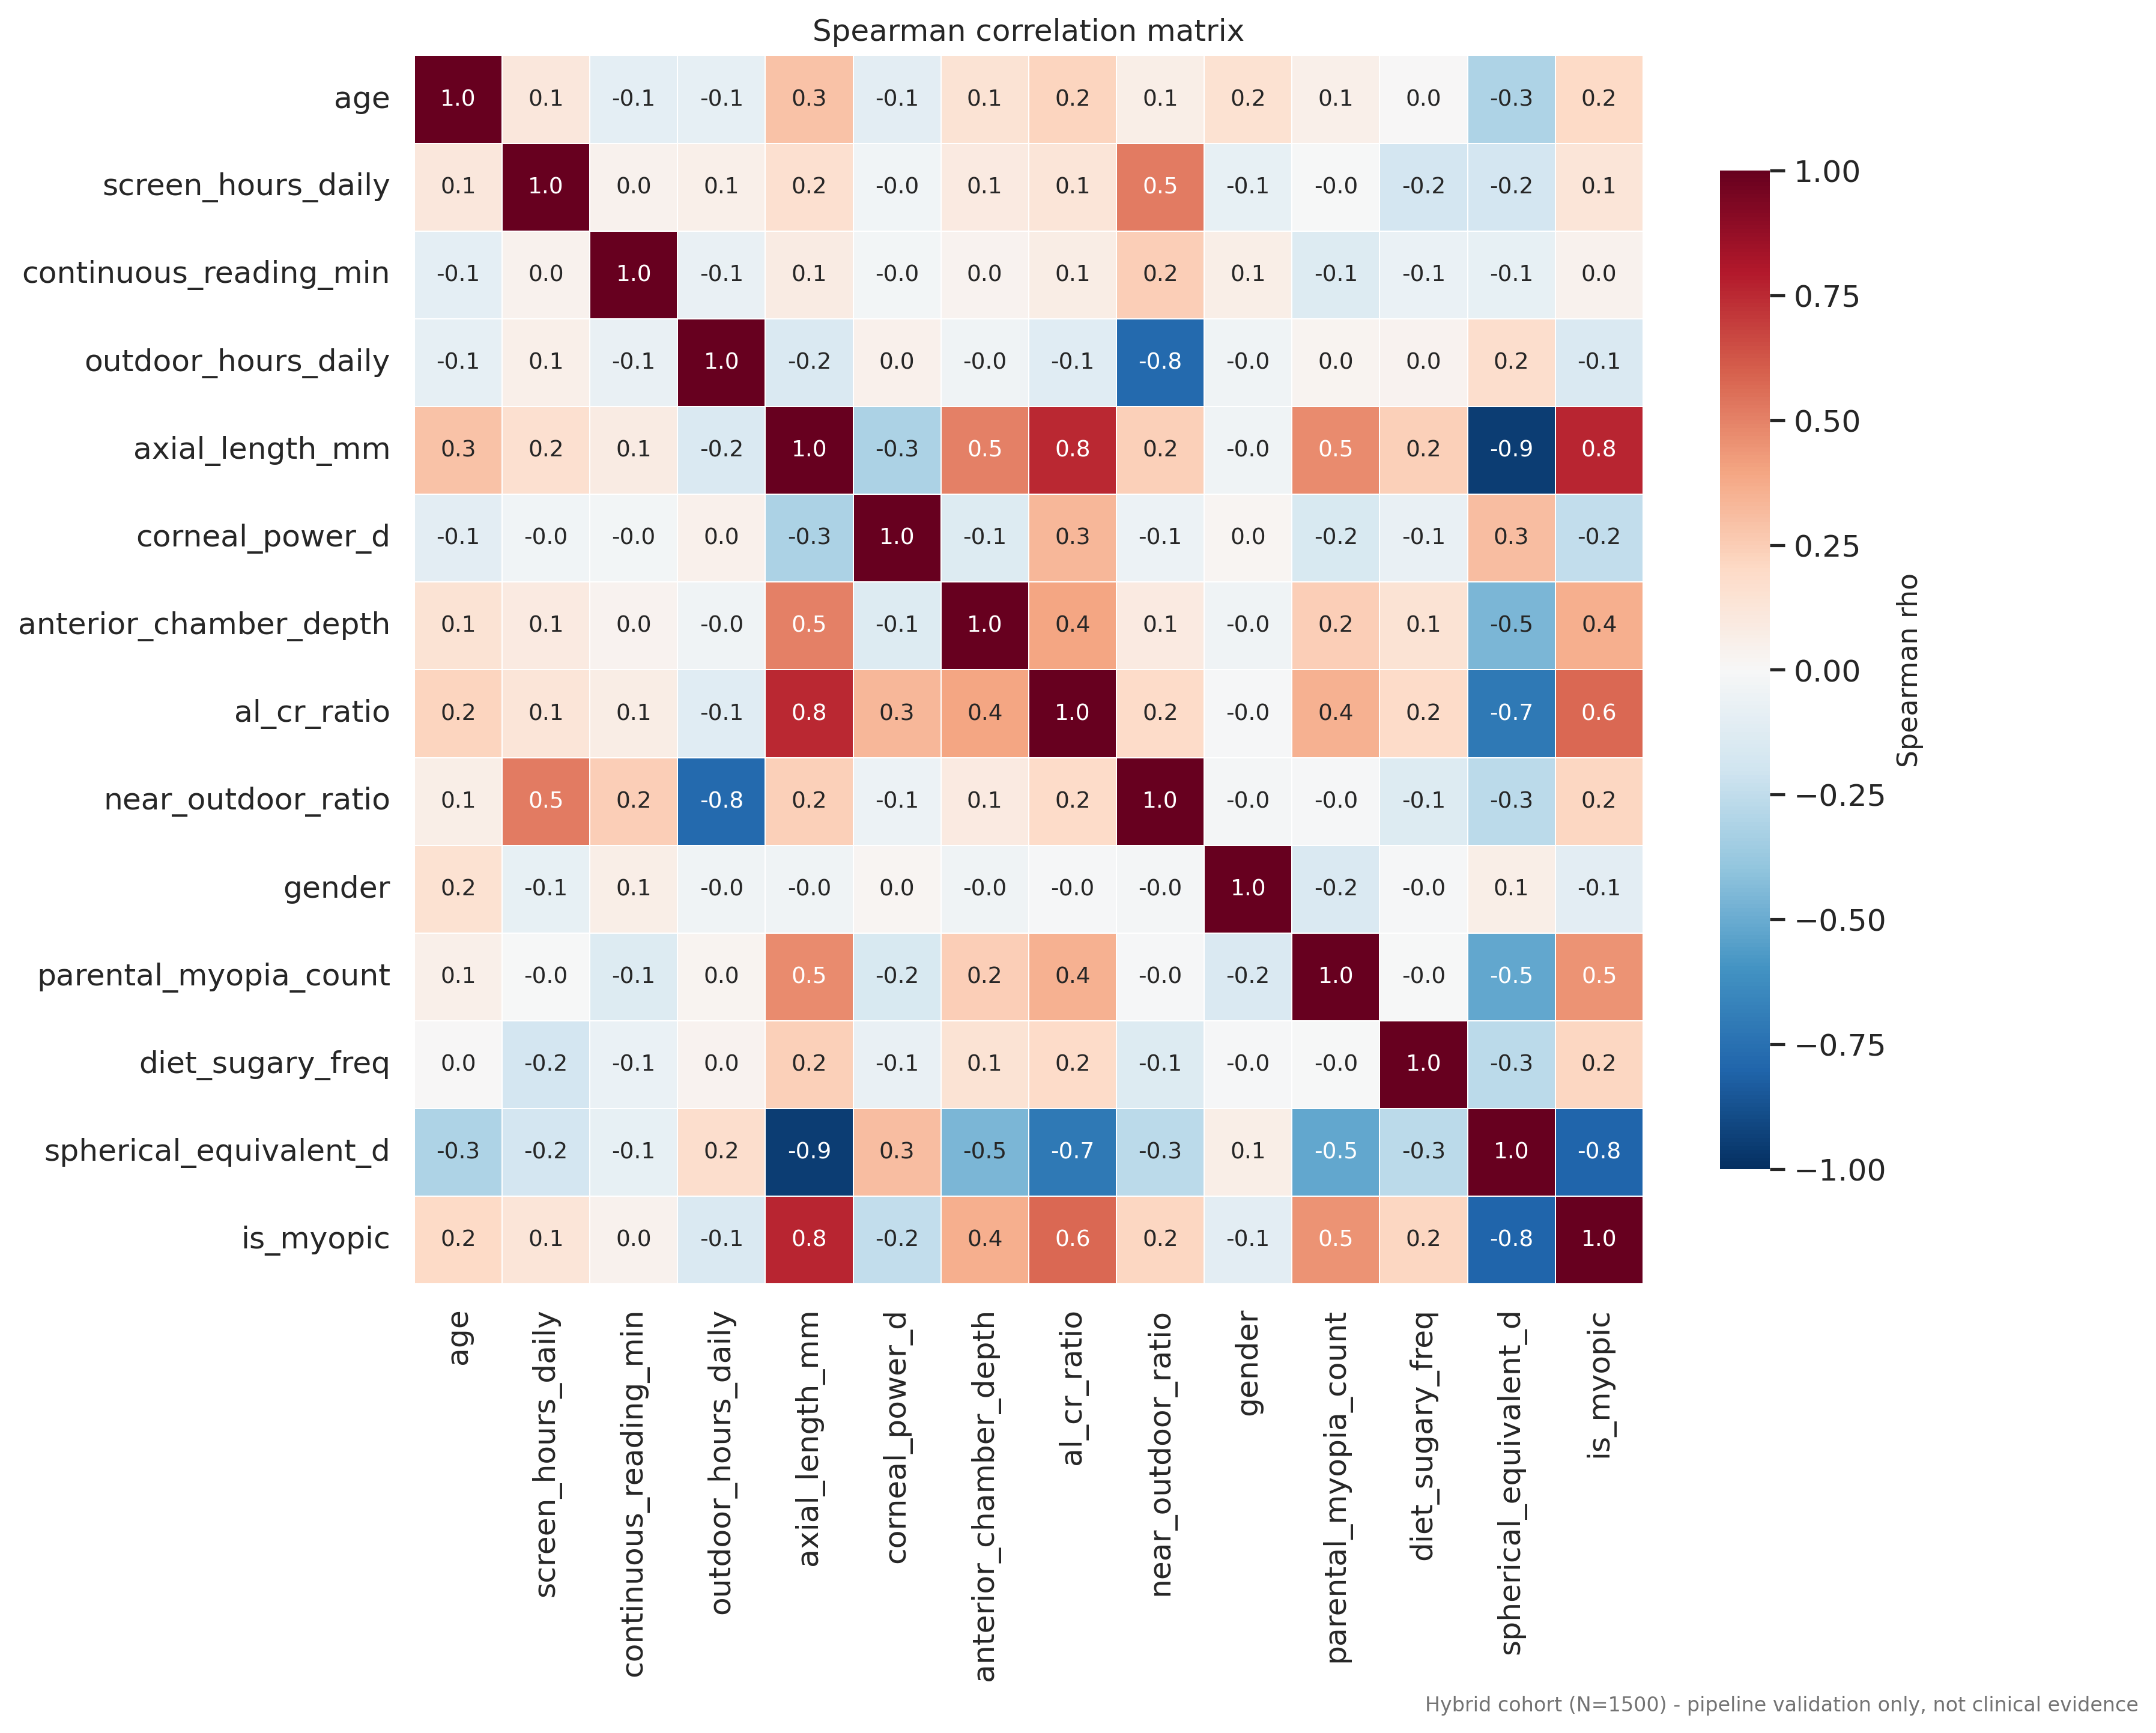

In [ ]:
heat_cols = FSPEC["numeric"] + FSPEC["categorical"] + ["spherical_equivalent_d", TARGET]
corr = df[heat_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.4, cbar_kws={"label": "Spearman rho", "shrink": 0.8}, annot_kws={"size": 9}, ax=ax)
ax.set_title("Spearman correlation matrix")
fig_paths += save_figure(fig, "fig8_heatmap")
show_saved("fig8_heatmap")

In [ ]:
out = {"prev": DIRS["tables"] / "table7_prevalence_by_age.csv", "corr": DIRS["tables"] / "table8_spearman_matrix.csv"}
prev_df.assign(chi2=chi2, chi2_p=p_chi).to_csv(out["prev"], index=False)
corr.to_csv(out["corr"])
register_outputs(STEP, list(out.values()) + fig_paths, {"n_figures": len(fig_paths) // 2})
print("=" * 70)
print(f"05 DONE | figures written: {sorted({p.stem for p in fig_paths})}")
print(f"NEXT -> open {NOTEBOOKS['06_export']} and Run all")

Manifest updated: step '05_figures' -> 6 files registered.
05 DONE | figures written: ['fig5_roc_train_test', 'fig8_heatmap']
NEXT -> open SoftCom_06_Export.ipynb and Run all
